# 01 — Data Preparation: Bubble Label Generation

This notebook generates **all bubble label variants** from two detection methods:

| Method | Source | Description |
|--------|--------|-------------|
| **GSADF** | `R/df_master.csv` | Pre-computed in R using the Phillips et al. (2015) GSADF test. Labels entire periods as bubbles. |
| **LPPLS** | `R/lppls_confidence.csv` | Daily positive-confidence from the Sornette LPPLS model. Needs thresholding + post-processing. |

### LPPLS Variants

We test multiple confidence thresholds and two label styles:

| Variant | Threshold | Style | Rationale |
|---------|-----------|-------|-----------|
| `lppls_0.30` | conf ≥ 0.30 | Point-wise | Strict — only high-confidence days |
| `lppls_0.20` | conf ≥ 0.20 | Point-wise | Moderate |
| `lppls_0.10` | conf ≥ 0.10 | Point-wise | Permissive |
| `lppls_0.05` | conf ≥ 0.05 | Point-wise | Very permissive |
| `lppls_period` | conf ≥ 0.05 smoothed | Period-based | Smoothed + gap-bridged + min duration |

All LPPLS variants apply a **trend filter**: a day is only flagged if `price[t] > price[t-5]`.

### Output

A single file `outputs/all_labels.parquet` with columns:
- `Date`, price columns, feature columns
- `{METAL}_gsadf` — GSADF bubble flag
- `{METAL}_lppls_0.30` through `{METAL}_lppls_period` — LPPLS variants

This is the **single source of truth** for model training.

In [8]:
import pandas as pd, numpy as np, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)

# ── Load base data ───────────────────────────────────────────────────────
df = pd.read_csv('../R/df_master.csv', sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── Load cached LPPLS confidence ─────────────────────────────────────────
conf_df = pd.read_csv('../R/lppls_confidence.csv', index_col=0)

METALS = {
    'Cobalt':  'CODALY',
    'Copper':  'CUDALY',
    'Lithium': 'LIDALY',
    'Nickel':  'NIDALY',
}

TREND_LAG = 5

print(f'Period: {df["Date"].min().date()} → {df["Date"].max().date()}  ({len(df)} days)')
print(f'Metals: {list(METALS.keys())}')
print(f'LPPLS confidence columns: {[c for c in conf_df.columns if "_conf" in c]}')

Period: 2017-05-10 → 2025-10-31  (2152 days)
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
LPPLS confidence columns: ['CODALY_conf', 'CUDALY_conf', 'LIDALY_conf', 'NIDALY_conf']


## 1. GSADF Labels (from R)

These come directly from `df_master.csv` as `*_BD` columns.  
The GSADF test identifies entire **contiguous periods** of explosive behaviour.

In [9]:
# ── Copy GSADF labels ────────────────────────────────────────────────────
labels = df[['Date']].copy()

print('GSADF bubble labels:')
print(f'{"Metal":10s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}  {"Avg Len":>7s}')
print('-' * 44)

def count_episodes(arr):
    """Return (n_episodes, avg_length) for a binary array."""
    d = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if len(starts) == 0:
        return 0, 0.0
    lengths = ends - starts
    return len(starts), float(np.mean(lengths))

for metal, col in METALS.items():
    gsadf = df[col + '_BD'].values.astype(int)
    labels[f'{metal}_gsadf'] = gsadf
    n = int(gsadf.sum())
    n_ep, avg_l = count_episodes(gsadf)
    print(f'{metal:10s}  {n:5d}  {100*n/len(df):5.1f}%  {n_ep:8d}  {avg_l:6.1f}d')

GSADF bubble labels:
Metal        Days   Prev%  Episodes  Avg Len
--------------------------------------------
Cobalt        230   10.7%        16    14.4d
Copper         39    1.8%         6     6.5d
Lithium      1089   50.6%        13    83.8d
Nickel         26    1.2%         3     8.7d


## 2. LPPLS Point-Wise Labels (multiple thresholds)

For each threshold, flag day $t$ as bubble if:
1. `pos_conf[t] >= threshold`
2. `price[t] > price[t - 5]` (trend filter)

In [10]:
LPPLS_THRESHOLDS = [0.30, 0.20, 0.10, 0.05]

# Load confidence arrays
lppls_conf = {}
for metal, col in METALS.items():
    if col + '_conf' in conf_df.columns:
        lppls_conf[metal] = conf_df[col + '_conf'].values
    else:
        lppls_conf[metal] = np.zeros(len(df))

print('LPPLS point-wise labels (with trend filter):')
print(f'{"":10s}', end='')
for thr in LPPLS_THRESHOLDS:
    print(f'  {"conf≥" + str(thr):>12s}', end='')
print()
print('-' * (10 + 14 * len(LPPLS_THRESHOLDS)))

for metal, col in METALS.items():
    conf = lppls_conf[metal]
    prices = df[col].values
    print(f'{metal:10s}', end='')
    
    for thr in LPPLS_THRESHOLDS:
        flag = (conf >= thr).astype(int)
        # Trend filter
        for i in range(len(flag)):
            if flag[i] == 1 and i >= TREND_LAG:
                if prices[i] <= prices[i - TREND_LAG]:
                    flag[i] = 0
        labels[f'{metal}_lppls_{thr:.2f}'] = flag
        n = int(flag.sum())
        n_ep, _ = count_episodes(flag)
        print(f'  {n:4d}d/{n_ep:2d}ep', end='')
    print()

LPPLS point-wise labels (with trend filter):
                conf≥0.3      conf≥0.2      conf≥0.1     conf≥0.05
------------------------------------------------------------------
Cobalt        14d/ 4ep    20d/ 4ep    53d/ 7ep    64d/ 8ep
Copper        24d/12ep    54d/15ep   115d/25ep   143d/31ep
Lithium       12d/ 4ep    19d/ 6ep    59d/12ep    83d/15ep
Nickel        19d/ 5ep    44d/15ep   123d/27ep   129d/27ep


## 3. LPPLS Period-Based Labels

Converts scattered daily flags into coherent bubble **episodes** using a 4-step pipeline  
(following Cao et al. 2025; Zhang et al. 2016; Shu & Zhu 2020):

1. **Smooth** raw confidence with 5-day rolling mean
2. **Threshold** at conf ≥ 0.05 + trend filter
3. **Bridge** gaps ≤ 5 days (morphological closing)
4. **Remove** episodes < 3 days

In [11]:
SMOOTH_WINDOW = 5
PERIOD_THR    = 0.05
MAX_GAP       = 5
MIN_DUR       = 3

print(f'Period-based:  smooth={SMOOTH_WINDOW}d  thr={PERIOD_THR}  gap≤{MAX_GAP}d  min_dur≥{MIN_DUR}d')
print(f'{"Metal":10s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}  {"Avg Len":>7s}')
print('-' * 44)

for metal, col in METALS.items():
    conf   = lppls_conf[metal]
    prices = df[col].values
    n      = len(conf)
    
    # Step 1: Smooth
    smoothed = pd.Series(conf).rolling(SMOOTH_WINDOW, min_periods=1).mean().values
    
    # Step 2: Threshold + trend
    flag = (smoothed >= PERIOD_THR).astype(int)
    for i in range(n):
        if flag[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                flag[i] = 0
    
    # Step 3: Bridge gaps
    i = 0
    while i < n:
        if flag[i] == 0:
            j = i
            while j < n and flag[j] == 0:
                j += 1
            if (j - i) <= MAX_GAP and i > 0 and j < n:
                flag[i:j] = 1
            i = j
        else:
            i += 1
    
    # Step 4: Remove short episodes
    i = 0
    while i < n:
        if flag[i] == 1:
            j = i
            while j < n and flag[j] == 1:
                j += 1
            if (j - i) < MIN_DUR:
                flag[i:j] = 0
            i = j
        else:
            i += 1
    
    labels[f'{metal}_lppls_period'] = flag
    n_days = int(flag.sum())
    n_ep, avg_l = count_episodes(flag)
    print(f'{metal:10s}  {n_days:5d}  {100*n_days/len(df):5.1f}%  {n_ep:8d}  {avg_l:6.1f}d')

Period-based:  smooth=5d  thr=0.05  gap≤5d  min_dur≥3d
Metal        Days   Prev%  Episodes  Avg Len
--------------------------------------------
Cobalt         71    3.3%         5    14.2d
Copper        179    8.3%        15    11.9d
Lithium        73    3.4%        10     7.3d
Nickel        193    9.0%        10    19.3d


## 4. Summary Overview & Save

In [12]:
import matplotlib.pyplot as plt

# ── Summary table ────────────────────────────────────────────────────────
variant_names = ['gsadf'] + [f'lppls_{t:.2f}' for t in LPPLS_THRESHOLDS] + ['lppls_period']

print('\n' + '=' * 80)
print('SUMMARY: Bubble Days & Episodes per Metal × Label Variant')
print('=' * 80)
header = f'{"Metal":10s}'
for v in variant_names:
    header += f'  {v:>14s}'
print(header)
print('-' * (10 + 16 * len(variant_names)))

for metal in METALS:
    row = f'{metal:10s}'
    for v in variant_names:
        col_name = f'{metal}_{v}'
        if col_name in labels.columns:
            arr = labels[col_name].values
            n = int(arr.sum())
            n_ep, _ = count_episodes(arr)
            row += f'  {n:4d}d/{n_ep:2d}ep'
        else:
            row += f'  {"N/A":>14s}'
    print(row)

# ── Merge labels with price data for output ──────────────────────────────
price_cols = list(METALS.values())  # CODALY, CUDALY, LIDALY, NIDALY
extra_cols = [c for c in df.columns if c not in ['Date'] + price_cols + [c+'_BD' for c in price_cols]]

output = df[['Date'] + price_cols + extra_cols].copy()
for col in labels.columns:
    if col != 'Date':
        output[col] = labels[col].values

out_path = '../outputs/all_labels.csv'
output.to_csv(out_path, index=False)
print(f'\nSaved → {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB)')
print(f'Columns: {len(output.columns)}  Rows: {len(output)}')


SUMMARY: Bubble Days & Episodes per Metal × Label Variant
Metal                gsadf      lppls_0.30      lppls_0.20      lppls_0.10      lppls_0.05    lppls_period
----------------------------------------------------------------------------------------------------------
Cobalt       230d/16ep    14d/ 4ep    20d/ 4ep    53d/ 7ep    64d/ 8ep    71d/ 5ep
Copper        39d/ 6ep    24d/12ep    54d/15ep   115d/25ep   143d/31ep   179d/15ep
Lithium     1089d/13ep    12d/ 4ep    19d/ 6ep    59d/12ep    83d/15ep    73d/10ep
Nickel        26d/ 3ep    19d/ 5ep    44d/15ep   123d/27ep   129d/27ep   193d/10ep

Saved → ../outputs/all_labels.csv  (487.3 KB)
Columns: 41  Rows: 2152


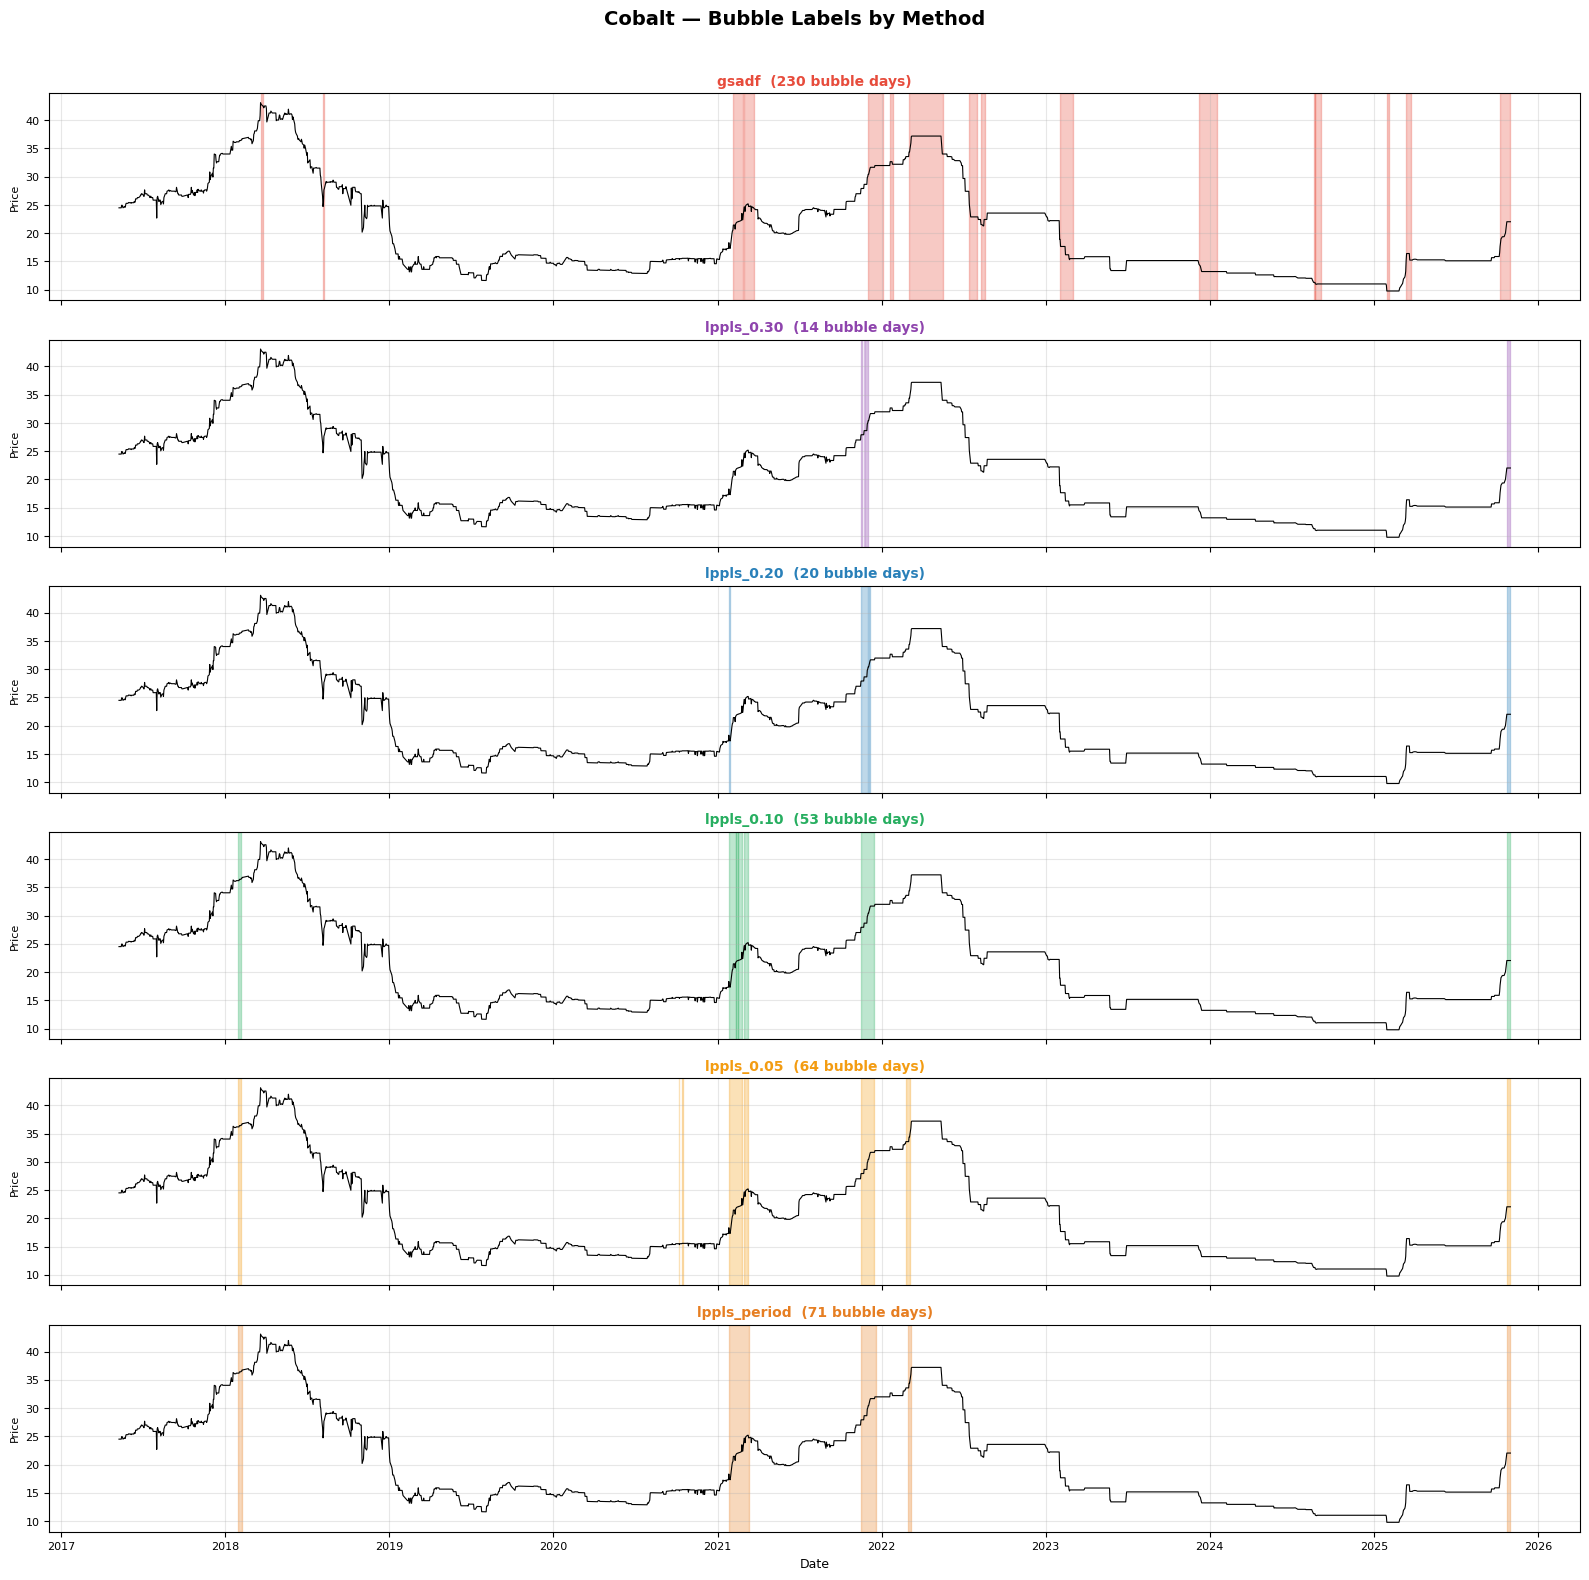

Saved → ../outputs/01_bubble_cobalt.png


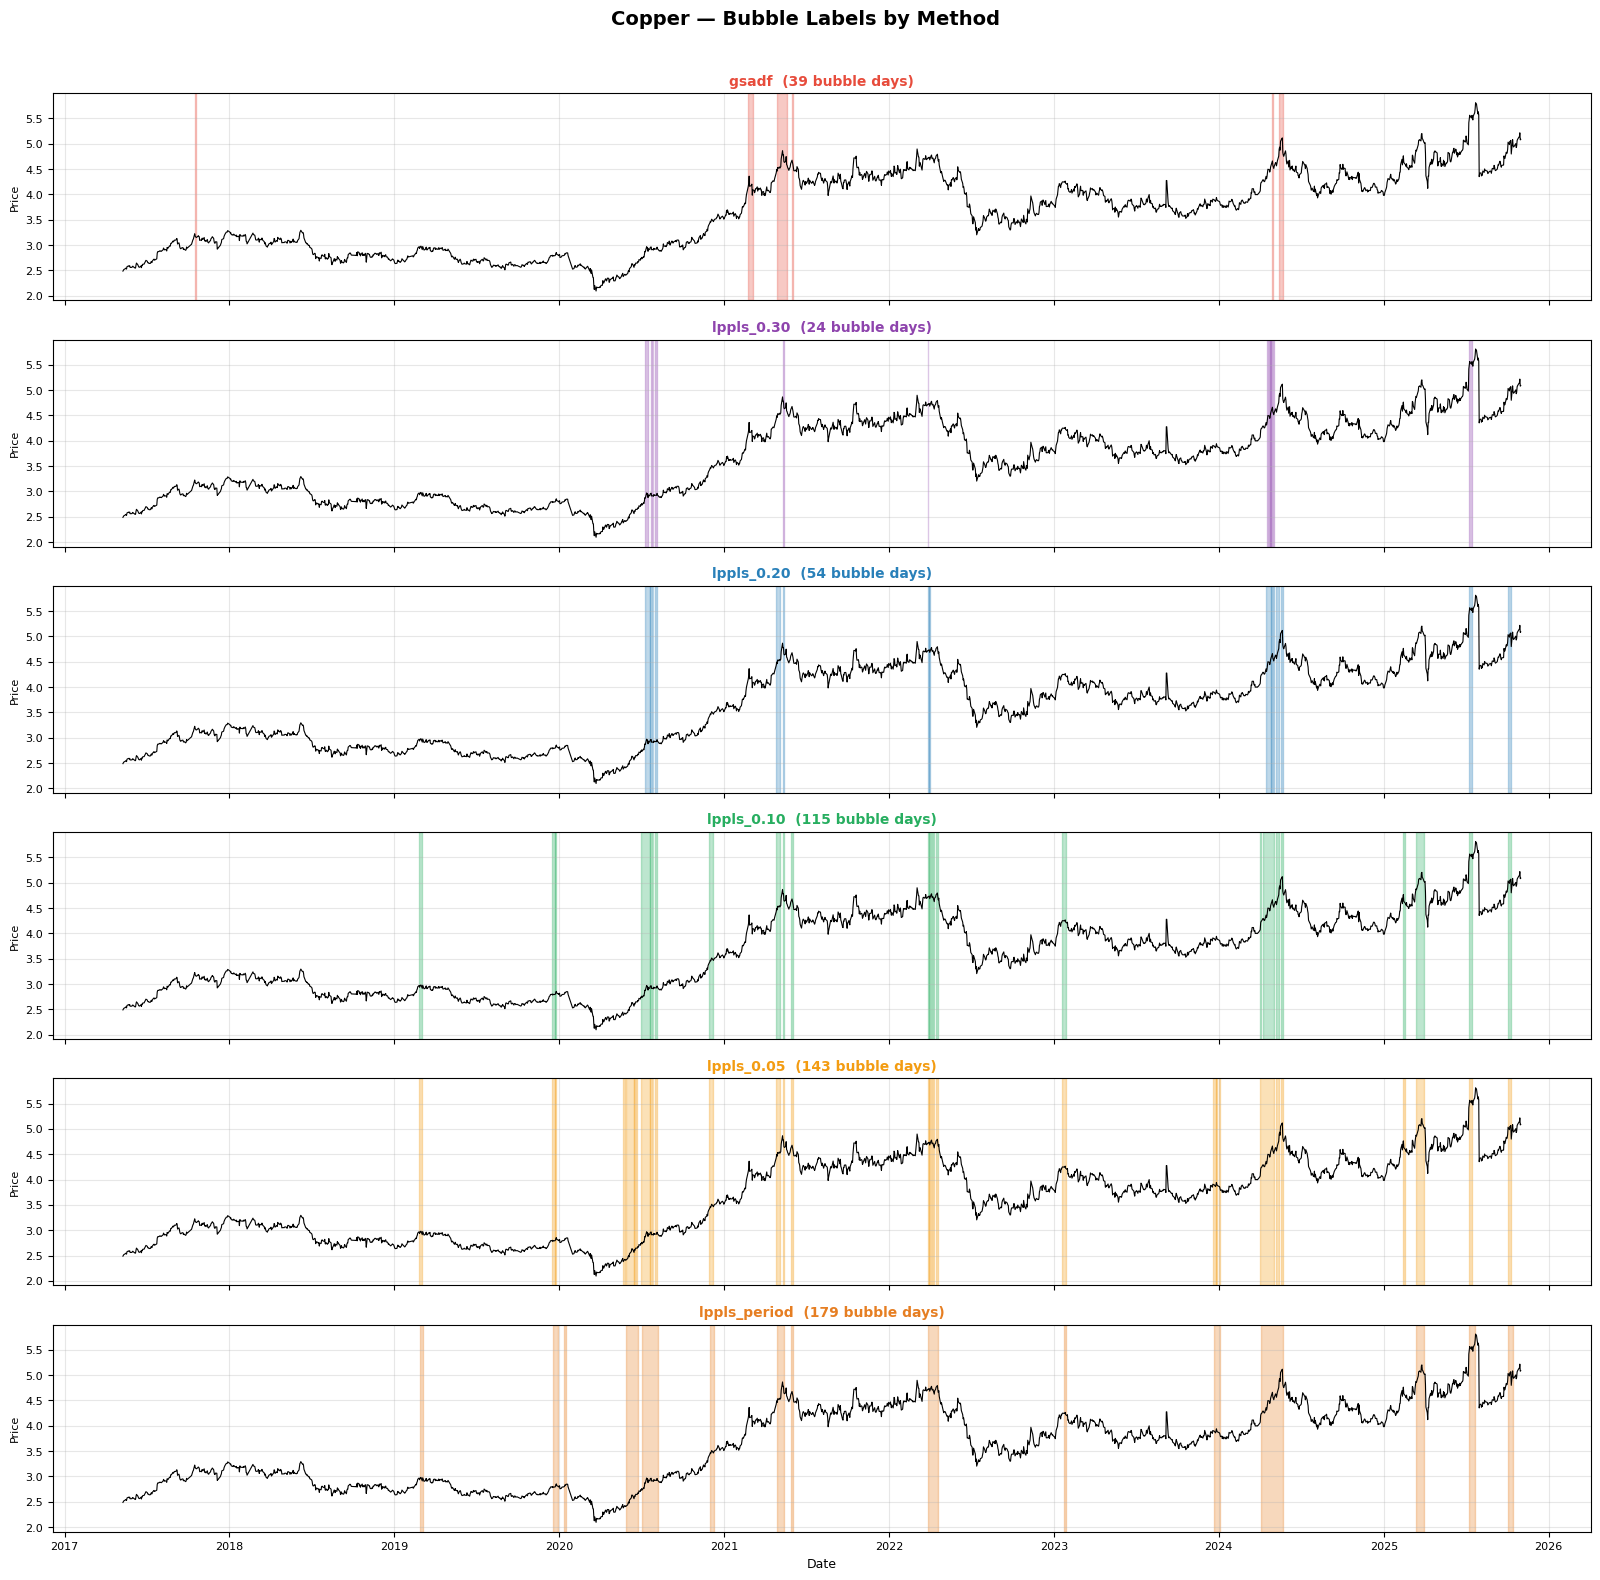

Saved → ../outputs/01_bubble_copper.png


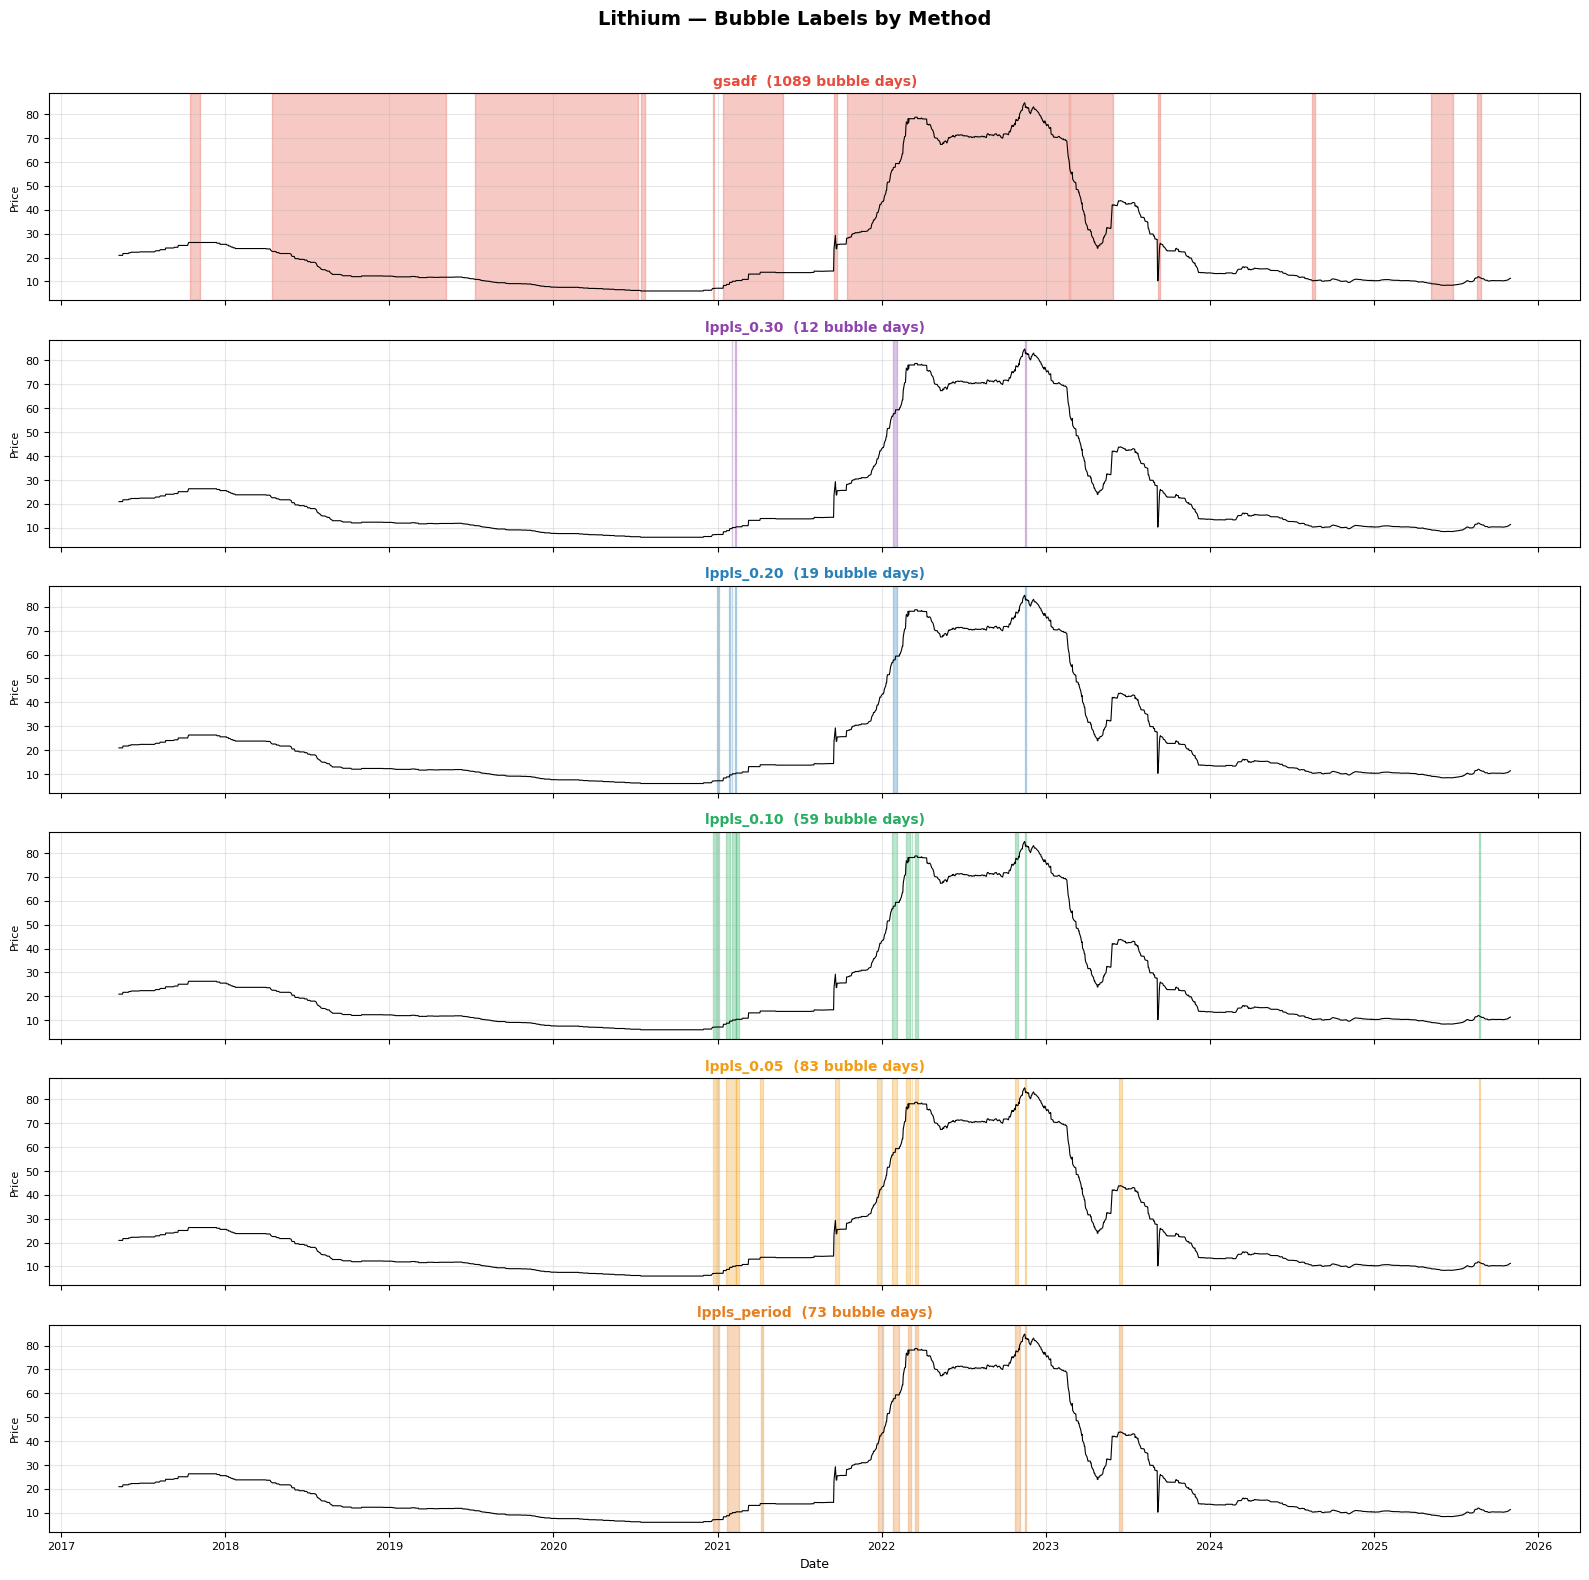

Saved → ../outputs/01_bubble_lithium.png


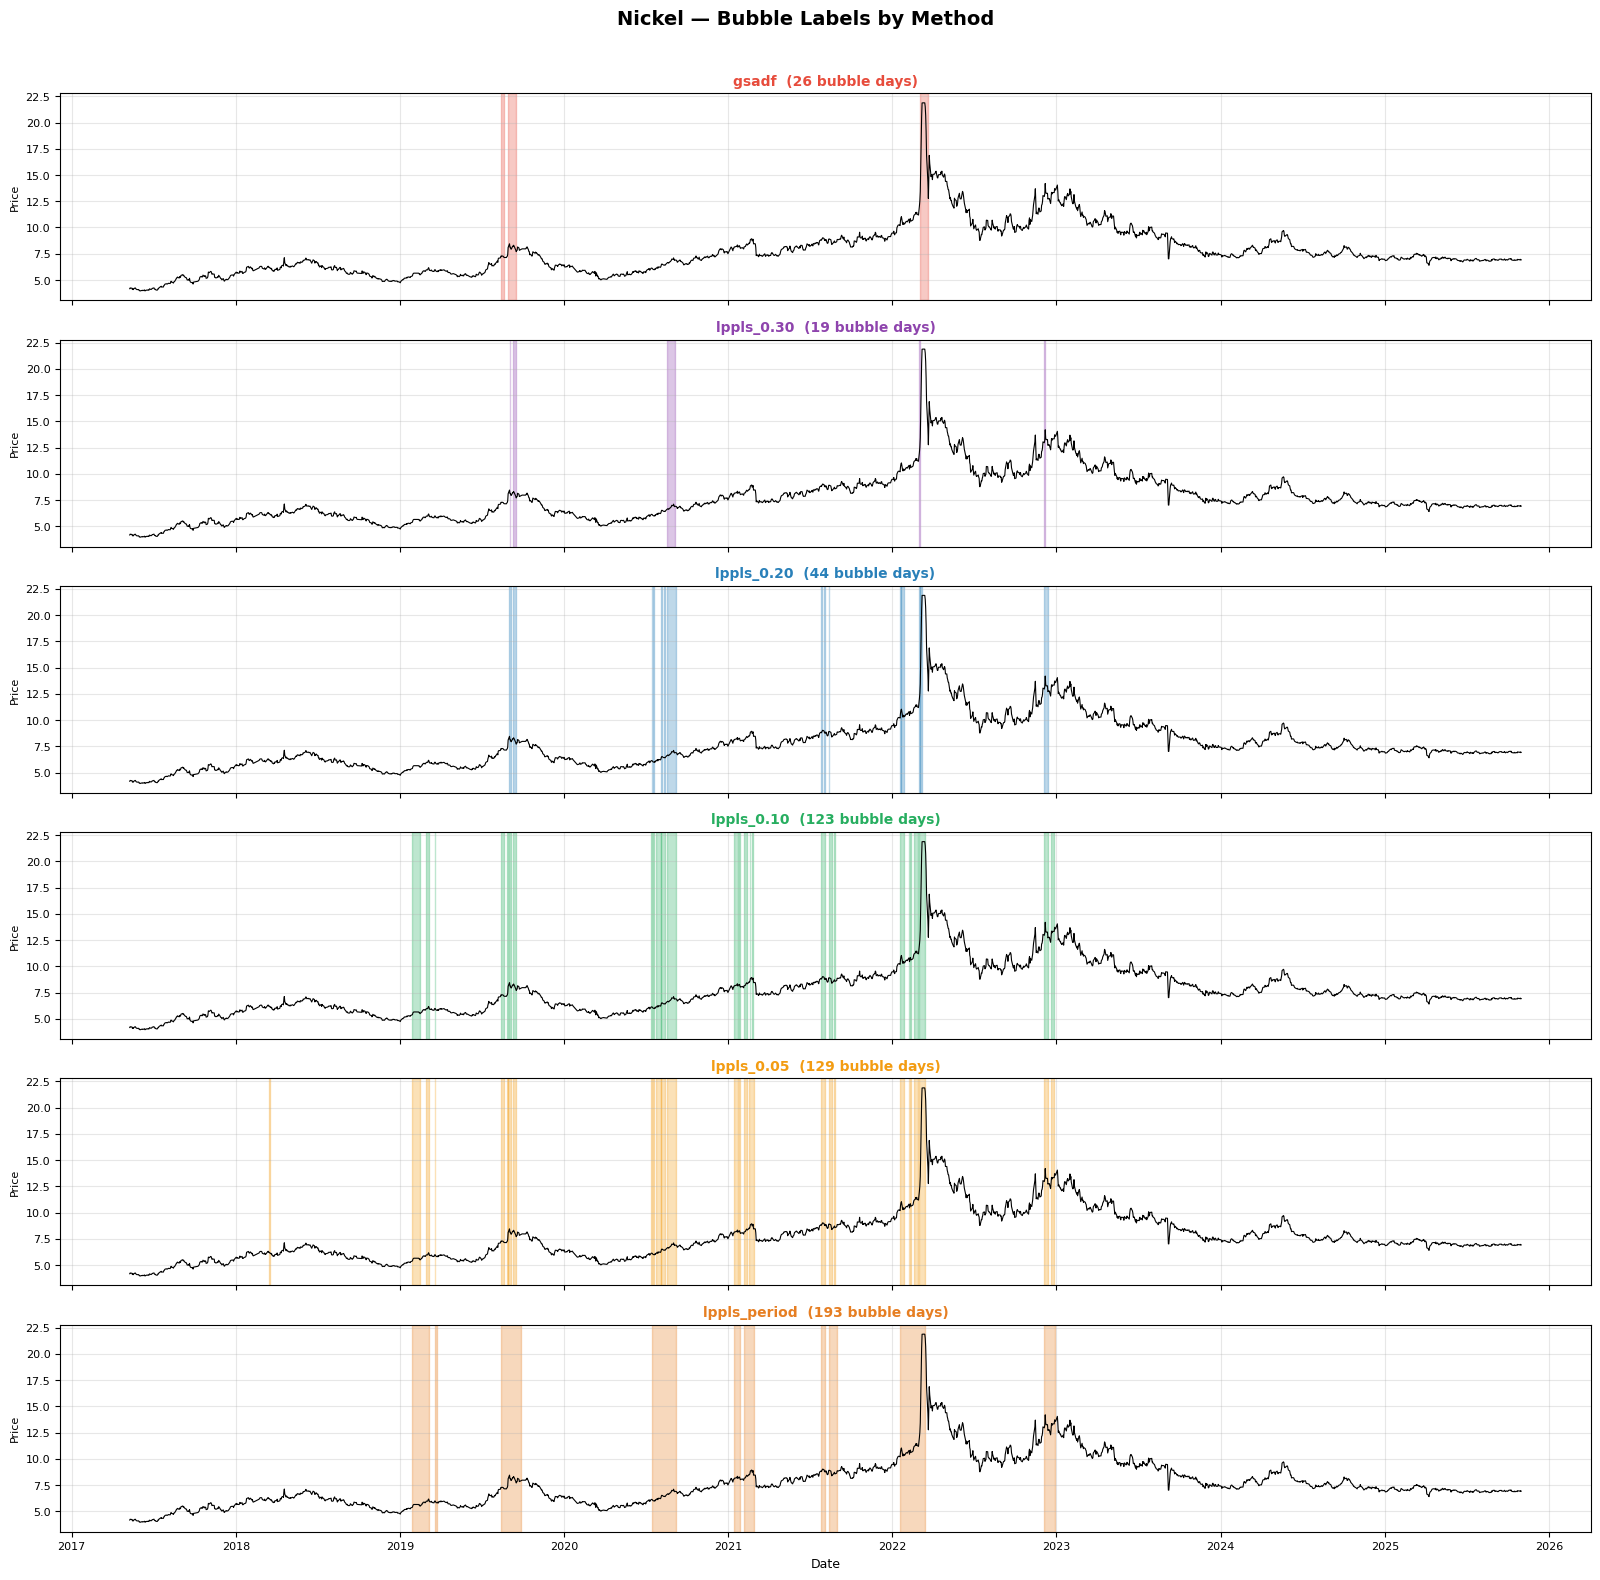

Saved → ../outputs/01_bubble_nickel.png
Done — all label variants generated.


In [13]:

# ── Visual overview: one figure per metal, one row per label variant ──────
PLOT_VARIANTS = ['gsadf', 'lppls_0.30', 'lppls_0.20', 'lppls_0.10', 'lppls_0.05', 'lppls_period']
VARIANT_COLORS = {
    'gsadf':        '#e74c3c',
    'lppls_0.30':   '#8e44ad',
    'lppls_0.20':   '#2980b9',
    'lppls_0.10':   '#27ae60',
    'lppls_0.05':   '#f39c12',
    'lppls_period': '#e67e22',
}

for metal, col in METALS.items():
    n_v = len(PLOT_VARIANTS)
    fig, axes = plt.subplots(n_v, 1, figsize=(16, 2.6 * n_v), sharex=True)
    dates = output['Date']

    for ax, vname in zip(axes, PLOT_VARIANTS):
        ax.plot(dates, output[col], color='black', lw=0.8)

        label_col = f'{metal}_{vname}'
        n_days = 0
        if label_col in output.columns:
            arr = output[label_col].values
            n_days = int(arr.sum())
            color = VARIANT_COLORS[vname]
            in_b = False
            for i in range(len(arr)):
                if arr[i] == 1 and not in_b:
                    s = dates.iloc[i]
                    in_b = True
                elif (arr[i] == 0 or i == len(arr) - 1) and in_b:
                    ax.axvspan(s, dates.iloc[i], color=color, alpha=0.3)
                    in_b = False

        ax.set_ylabel('Price', fontsize=8)
        ax.set_title(f'{vname}  ({n_days} bubble days)',
                     fontsize=10, fontweight='bold', color=VARIANT_COLORS.get(vname, 'black'))
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Date', fontsize=9)
    plt.suptitle(f'{metal} — Bubble Labels by Method', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()

    out_path = f'../outputs/01_bubble_{metal.lower()}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

print('Done — all label variants generated.')
